# Time Series Models — Walkthrough

An integrated walkthrough covering: white noise, MA, AR, EWMA volatility, ARCH, and GARCH models.
Each section: LaTeX formula → code → chart.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
from arch import arch_model
plt.style.use('seaborn-v0_8')

## 1. White Noise — Uniform Distribution

A white noise process $\{\epsilon_t\}$ satisfies $E[\epsilon_t]=0$, $\mathrm{Var}(\epsilon_t)=\sigma^2$, and
uncorrelated across time. Here we simulate the uniform variant:

$$\epsilon_t \sim \mathrm{Uniform}(-1,\,1)$$

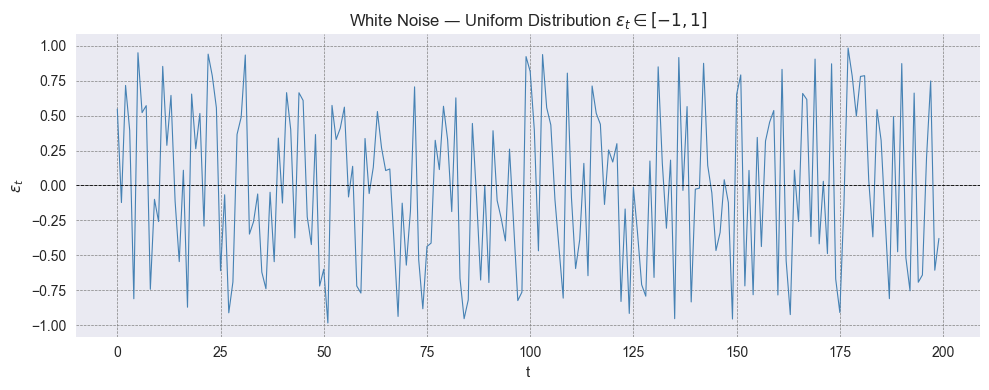

In [2]:
def simulate_white_noise_uniform(n_samples, seed):
    rng = np.random.default_rng(seed)
    return rng.uniform(-1.0, 1.0, size=n_samples)

noise = simulate_white_noise_uniform(200, 42)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(noise, linewidth=0.8, color='steelblue')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.set(title=r'White Noise — Uniform Distribution $\epsilon_t \in [-1, 1]$',
       xlabel='t', ylabel=r'$\epsilon_t$')
ax.grid(True, linestyle='--', linewidth=0.5, color='gray')
plt.tight_layout()
plt.show()

## 2. Moving Average (MA) Time Series

An MA(q) series is a weighted sum of current and past white noise:

$$Y_t = \epsilon_t + a_1\epsilon_{t-1} + a_2\epsilon_{t-2} + \cdots + a_q\epsilon_{t-q}$$

**Properties:**
- $E[Y_t] = 0$
- $\mathrm{Var}(Y_t) = (1 + a_1^2 + \cdots + a_q^2)\,\sigma^2$

Below we use MA(4) with weights $a_1=0.5,\;a_2=0.3,\;a_3=0.2,\;a_4=0.1$.

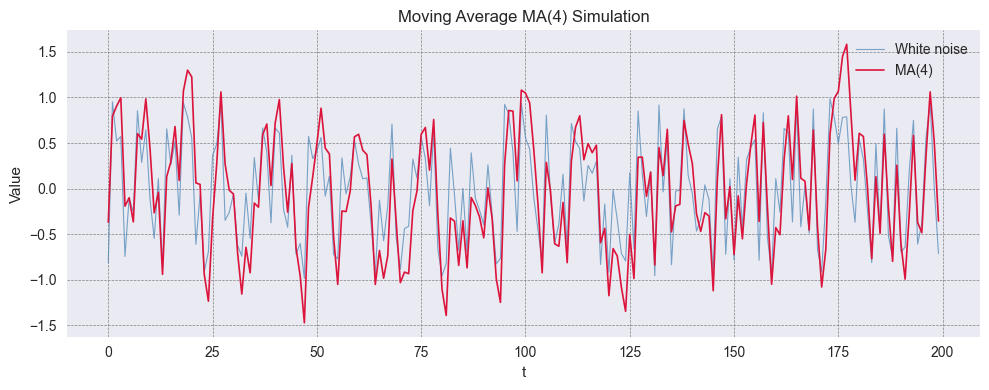

In [3]:
def simulate_ma(weights, n_samples, seed):
    coeffs = np.concatenate(([1.0], np.asarray(weights, dtype=float)))
    q = len(weights)
    rng = np.random.default_rng(seed)
    noise = rng.uniform(-1.0, 1.0, size=n_samples + q)
    ma_series = np.convolve(noise, coeffs, mode='full')[q: q + n_samples]
    return noise[q:], ma_series

ma_weights = [0.5, 0.3, 0.2, 0.1]
noise_ma, ma_series = simulate_ma(ma_weights, 200, 42)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(noise_ma, color='steelblue', linewidth=0.8, alpha=0.7, label='White noise')
ax.plot(ma_series, color='crimson', linewidth=1.2, label='MA(4)')
ax.set(title='Moving Average MA(4) Simulation', xlabel='t', ylabel='Value')
ax.legend()
ax.grid(True, linestyle='--', linewidth=0.5, color='gray')
plt.tight_layout()
plt.show()

## 3. Autoregressive (AR) Time Series

An AR(p) series linearly regresses on its own past values:

$$Y_t = b_1 Y_{t-1} + b_2 Y_{t-2} + \cdots + b_p Y_{t-p} + \epsilon_t$$

Below we simulate AR(2) with $b_1=0.5,\;b_2=0.3$.

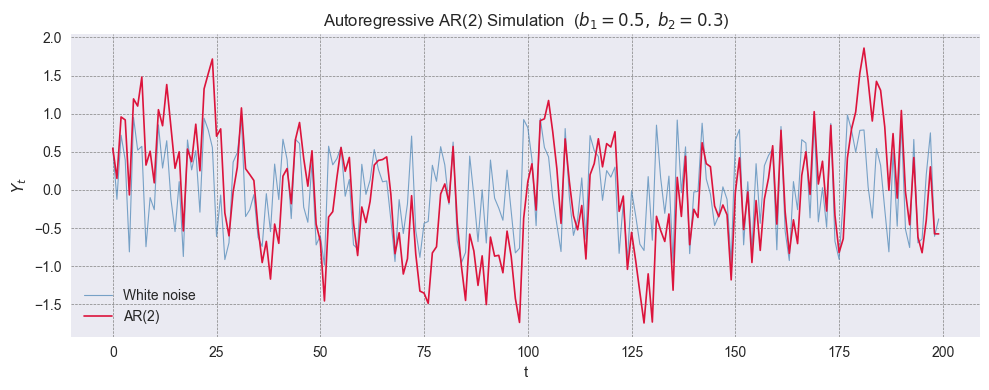

In [4]:
def simulate_ar(weights, n_samples, seed):
    weights = np.asarray(weights, dtype=float)
    p = len(weights)
    rng = np.random.default_rng(seed)
    noise = rng.uniform(-1.0, 1.0, size=n_samples)
    y = np.zeros(n_samples)
    for t in range(n_samples):
        lag_sum = sum(weights[i] * y[t - i - 1] for i in range(min(p, t)))
        y[t] = lag_sum + noise[t]
    return noise, y

ar_weights = [0.5, 0.3]
noise, ar_series = simulate_ar(ar_weights, 200, 42)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(noise, color='steelblue', linewidth=0.8, alpha=0.7, label='White noise')
ax.plot(ar_series, color='crimson', linewidth=1.2, label='AR(2)')
ax.set(title=r'Autoregressive AR(2) Simulation  ($b_1=0.5,\; b_2=0.3$)',
       xlabel='t', ylabel=r'$Y_t$')
ax.legend()
ax.grid(True, linestyle='--', linewidth=0.5, color='gray')
plt.tight_layout()
plt.show()

## 4. AAPL 2025 — EWMA Volatility Forecast

Log return: $R_t = \ln S_t - \ln S_{t-1}$

EWMA one-step ahead variance forecast:

$$\sigma_t^2 = (1-\lambda)\sum_{i=1}^{m}\lambda^{i-1}R_{t-i}^2, \quad 0 < \lambda < 1$$

We use $m=20$ and $\lambda=0.94$ (RiskMetrics standard).

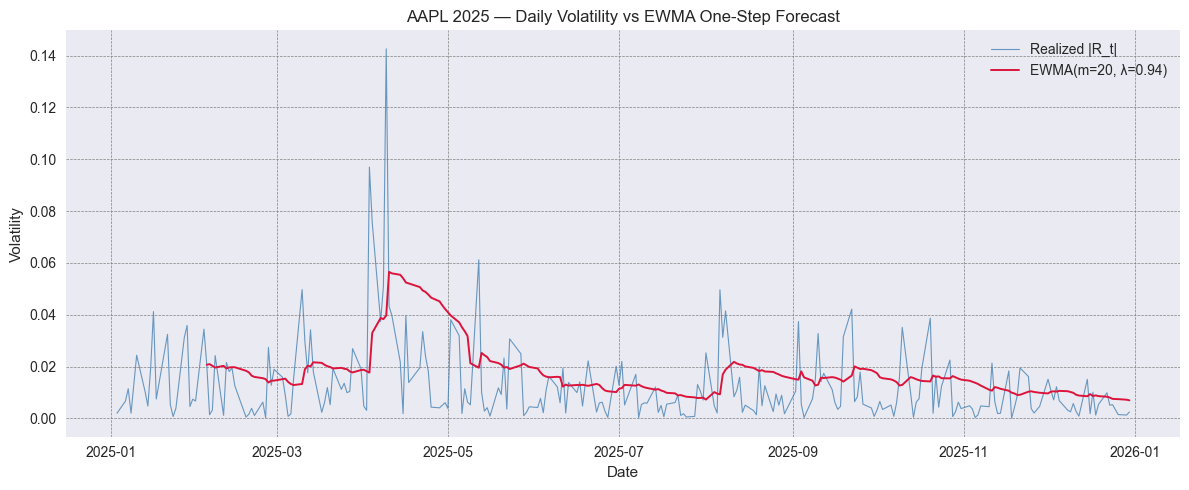

In [5]:
def fetch_log_returns(ticker, start, end):
    prices = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)['Close'].squeeze()
    log_ret = np.log(prices / prices.shift(1)).dropna()
    return log_ret

def compute_ewma_forecast(log_returns, m, lam):
    weights = (1 - lam) * lam ** np.arange(m)
    weights /= weights.sum()
    r2 = log_returns.values ** 2
    n = len(r2)
    forecast_var = np.full(n, np.nan)
    for t in range(m, n):
        forecast_var[t] = np.dot(weights, r2[t - m: t][::-1])
    return np.sqrt(forecast_var)

log_ret = fetch_log_returns('AAPL', '2025-01-01', '2025-12-31')
m_ewma, lam = 20, 0.94
ewma_forecast = compute_ewma_forecast(log_ret, m_ewma, lam)
realized_vol = log_ret.abs().values
dates = log_ret.index

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates, realized_vol, color='steelblue', linewidth=0.8, alpha=0.8, label='Realized |R_t|')
ax.plot(dates, ewma_forecast, color='crimson', linewidth=1.4,
        label=f'EWMA(m={m_ewma}, \u03bb={lam})')
ax.set(title='AAPL 2025 — Daily Volatility vs EWMA One-Step Forecast',
       xlabel='Date', ylabel='Volatility')
ax.legend()
ax.grid(True, linestyle='--', linewidth=0.5, color='gray')
plt.tight_layout()
plt.show()

## 5. AAPL 2025 — ARCH Model

The ARCH(p) model specifies:

$$\sigma_t^2 = \alpha_0 + \alpha_1 R_{t-1}^2 + \alpha_2 R_{t-2}^2 + \cdots + \alpha_p R_{t-p}^2$$

Parameters $\alpha_i$ are estimated by maximum likelihood (log-likelihood):

$$\ell_t = -\frac{1}{2}\left(\ln\sigma_t^2 + \frac{R_t^2}{\sigma_t^2}\right)$$

We use the `arch` package with ARCH(2).

Estimated ARCH parameters:
omega       2.386491
alpha[1]    0.395040
alpha[2]    0.000000


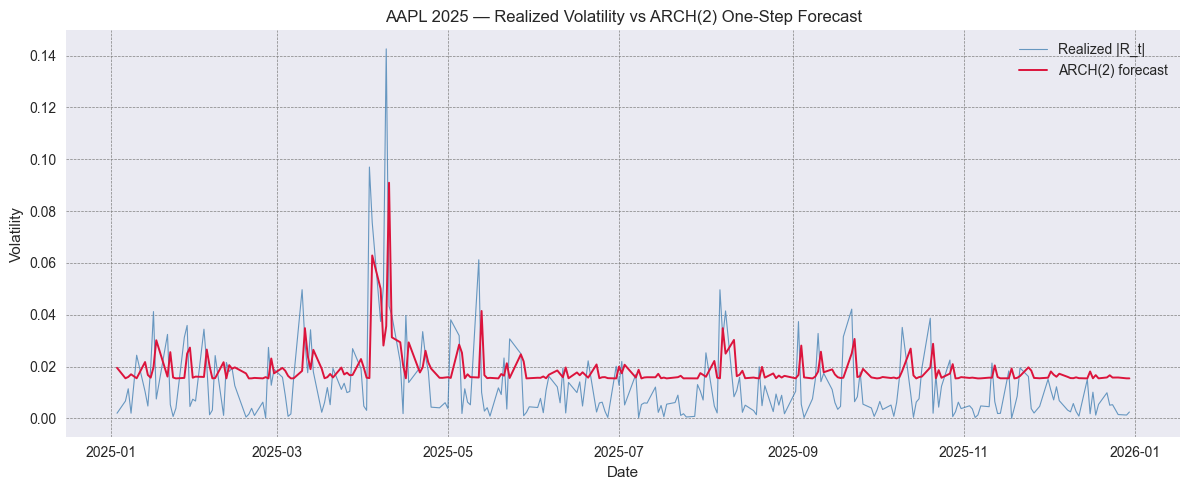

In [6]:
def fit_arch(log_returns, p):
    r_scaled = log_returns * 100
    model = arch_model(r_scaled, vol='ARCH', p=p, mean='Zero', dist='Normal')
    result = model.fit(disp='off')
    cond_vol = result.conditional_volatility / 100
    return result, cond_vol

p_arch = 2
arch_result, arch_cond_vol = fit_arch(log_ret, p_arch)
print('Estimated ARCH parameters:')
print(arch_result.params.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates, realized_vol, color='steelblue', linewidth=0.8, alpha=0.8, label='Realized |R_t|')
ax.plot(dates, arch_cond_vol.values, color='crimson', linewidth=1.4,
        label=f'ARCH({p_arch}) forecast')
ax.set(title=f'AAPL 2025 — Realized Volatility vs ARCH({p_arch}) One-Step Forecast',
       xlabel='Date', ylabel='Volatility')
ax.legend()
ax.grid(True, linestyle='--', linewidth=0.5, color='gray')
plt.tight_layout()
plt.show()

## 6. AAPL 2025 — GARCH Model

The GARCH(p, q) model extends ARCH by including past conditional variances:

$$\sigma_t^2 = \alpha_0 + \sum_{i=1}^{p}\alpha_i R_{t-i}^2 + \sum_{j=1}^{q}\beta_j\sigma_{t-j}^2$$

where $\alpha_0>0$, $\alpha_i\ge 0$, $\beta_j\ge 0$.

We use the standard GARCH(1,1).

Estimated GARCH parameters:
omega       0.166436
alpha[1]    0.130325
beta[1]     0.832140


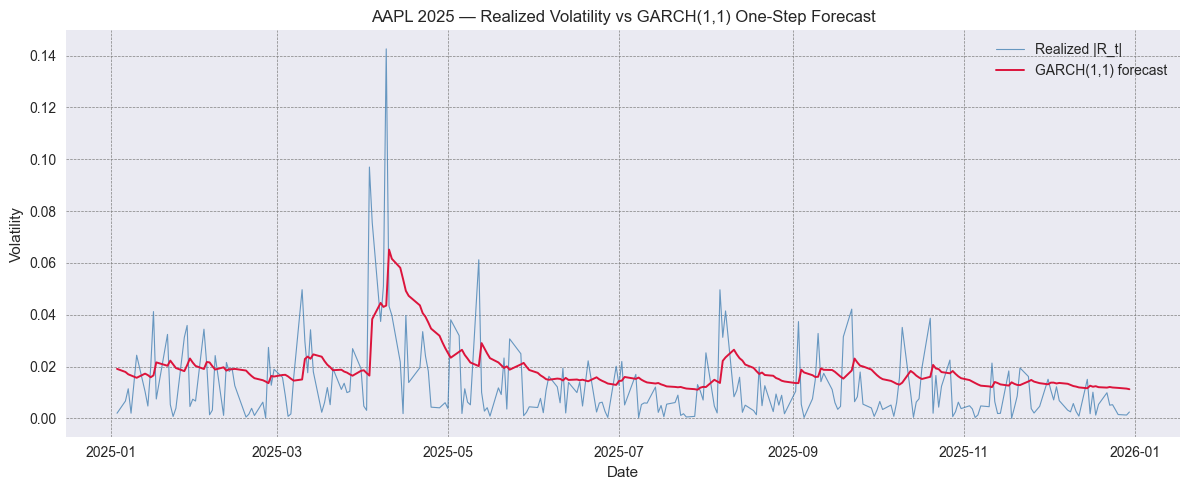

In [7]:
def fit_garch(log_returns, p, q):
    r_scaled = log_returns * 100
    model = arch_model(r_scaled, vol='Garch', p=p, q=q, mean='Zero', dist='Normal')
    result = model.fit(disp='off')
    cond_vol = result.conditional_volatility / 100
    return result, cond_vol

p_garch, q_garch = 1, 1
garch_result, garch_cond_vol = fit_garch(log_ret, p_garch, q_garch)
print('Estimated GARCH parameters:')
print(garch_result.params.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates, realized_vol, color='steelblue', linewidth=0.8, alpha=0.8, label='Realized |R_t|')
ax.plot(dates, garch_cond_vol.values, color='crimson', linewidth=1.4,
        label=f'GARCH({p_garch},{q_garch}) forecast')
ax.set(title=f'AAPL 2025 — Realized Volatility vs GARCH({p_garch},{q_garch}) One-Step Forecast',
       xlabel='Date', ylabel='Volatility')
ax.legend()
ax.grid(True, linestyle='--', linewidth=0.5, color='gray')
plt.tight_layout()
plt.show()